# Physics-Informed Neural Networks for a 2D Poisson Equation

Arnaja Mitra  

This notebook is created following the 2D PINN Poisson example developed by **Xiaofeng (George) Xu** and available in the GitHub repository:

https://github.com/georgexxu/Data-driven-Model-Discovery-Neural-Operators/blob/main/pinns/pinn2d.py

The purpose of this notebook is to provide a step-by-step introduction to Physics-Informed Neural Networks (PINNs) for solving a two-dimensional boundary value problem using automatic differentiation.

## Imports and setup

We import PyTorch, plotting tools, and set the computation device. If a GPU is available, the code uses the GPU; otherwise, it uses the CPU.

In [151]:
import sys
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)

torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Python: /opt/anaconda3/bin/python
PyTorch: 2.4.1
Device: cpu


## Reproducibility

To ensure that results are reproducible across multiple runs, we fix the random seed for Python, NumPy, and PyTorch.

In [154]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Define the PINN model

The boundary value problem under consideration is given by $\Delta u(x,y)+f(x,y)=0, \; (x,y)\in(0,1)^2$, subject to the homogeneous Dirichlet boundary condition $u(x,y)=0, \; (x,y)\in \partial[0,1]^2$.

To impose the boundary condition exactly, the PINN approximation is written as $u_\theta(x,y)=x(1-x)y(1-y)N_\theta(x,y)$, where $N_\theta(x,y)$ denotes a neural network with trainable parameters $\theta$. Since the factor $x(1-x)y(1-y)$ vanishes on the boundary of the unit square, the boundary condition is automatically satisfied.

The neural network architecture consists of an input layer with two neurons corresponding to the spatial variables $x$ and $y$, a single hidden layer comprising $100$ neurons, the $\tanh$ activation function, and an output layer that approximates the solution.

In [157]:
class PINN(nn.Module):
    def __init__(self, hidden_size, activation="tanh", relu_k=1):
        super().__init__()
        self.fc1 = nn.Linear(2, hidden_size)
        self.fc2 = nn.Linear(hidden_size, 1)
        self.activation = activation
        self.relu_k = relu_k

    def _activate(self, z):
        if self.activation == "tanh":
            return torch.tanh(z)
        if self.activation == "relu":
            return torch.relu(z).pow(self.relu_k)
        raise ValueError(f"Unknown activation: {self.activation!r}. Use 'tanh' or 'relu'.")

    def forward(self, xy):
        x, y = xy[:, 0:1], xy[:, 1:2]
        u = self._activate(self.fc1(xy))
        u = self.fc2(u)

        return x * (1 - x) * y * (1 - y) * u

## Define the Laplacian

The two-dimensional Poisson equation involves the Laplacian operator $\Delta u = u_{xx}+u_{yy}$.

In this cell, PyTorch automatic differentiation is used to compute the first derivatives $u_x$ and $u_y$, followed by the second derivatives $u_{xx}$ and $u_{yy}$. Their sum gives the Laplacian of the PINN approximation.

In [159]:
def laplacian(model, xy):
    u = model(xy)

    grad_u = torch.autograd.grad(u,xy,torch.ones_like(u),create_graph=True,retain_graph=True)[0]

    u_x = grad_u[:, 0:1]
    u_y = grad_u[:, 1:2]

    u_xx = torch.autograd.grad(u_x,xy,torch.ones_like(u_x),create_graph=True,retain_graph=True)[0][:, 0:1]

    u_yy = torch.autograd.grad(u_y,xy,torch.ones_like(u_y),create_graph=True,retain_graph=True)[0][:, 1:2]

    return u_xx + u_yy

## Define the PDE loss

The trainable parameters of the neural network are determined by minimizing the residual of the two-dimensional Poisson equation at the prescribed collocation points.

Let $u_\theta(x,y)$ denote the PINN approximation. The residual is given by $R(x,y)=\Delta u_\theta(x,y)+f(x,y)$. The PDE loss is defined as $\mathcal{L}_{\mathrm{PDE}}=\frac{1}{N_c}\sum_{i=1}^{N_c}\left[\Delta u_\theta(x_i,y_i)+f(x_i,y_i)\right]^2$.

Since the boundary condition is imposed exactly through the ansatz $u_\theta(x,y)=x(1-x)y(1-y)N_\theta(x,y)$, no additional boundary loss term is required.

In [162]:
def pde_loss(model, xy, f):
    lap_u = laplacian(model, xy)
    residual = lap_u.squeeze() + f

    return torch.mean(residual ** 2)

## Define relative $L^2$ error

To assess the accuracy of the PINN approximation, we compare the predicted solution with the exact solution on a set of test points in the unit square. The relative $L^2$ error is defined by $\frac{\|u_\theta-u_{\mathrm{exact}}\|_2}{\|u_{\mathrm{exact}}\|_2}$. A smaller relative $L^2$ error indicates better agreement between the PINN approximation and the exact solution.

In [166]:
def relative_l2_error(model, xy_test, u_test, l2_norm_exact):
    with torch.no_grad():
        u_pred = model(xy_test).squeeze()

        return torch.norm(u_pred - u_test) / l2_norm_exact

## Create the interior grid

The residual of the differential equation is evaluated at uniformly distributed interior collocation points in the domain $(0,1)^2$.

In this example, we use $50$ interior points in each spatial direction, giving $N_c=50^2=2500$ interior collocation points. The boundary points are excluded because the boundary condition is already imposed exactly through the PINN ansatz.

In [169]:
def make_interior_grid(n_per_axis, device):
    x_1d = torch.linspace(0, 1, n_per_axis + 2)[1:-1]
    y_1d = torch.linspace(0, 1, n_per_axis + 2)[1:-1]

    X, Y = torch.meshgrid(x_1d, y_1d, indexing="ij")

    xc = X.reshape(-1).to(device)
    yc = Y.reshape(-1).to(device)

    xy = torch.stack([xc, yc], dim=1).clone().requires_grad_(True)

    return xy, xc, yc, X, Y

## Exact solution and source term

For validation purposes, the exact solution is chosen as $u(x,y)=\frac{\sin(\omega x)\sin(\omega y)}{100}$. Using this exact solution, the source term $f(x,y)$ is constructed so that $\Delta u(x,y)+f(x,y)=0$. Since $\Delta u(x,y)=-\frac{2\omega^2}{100}\sin(\omega x)\sin(\omega y)$, we obtain $f(x,y)=\frac{2\omega^2}{100}\sin(\omega x)\sin(\omega y)$.

In [175]:
def exact_solution(xc, yc, omega):
    return torch.sin(omega * xc) * torch.sin(omega * yc) / 100.0


def source_term(xc, yc, omega):
    return 2 * omega**2 * torch.sin(omega * xc) * torch.sin(omega * yc) / 100.0

## Define the parameters

In this example, we take $\omega=10$, which controls the oscillatory behavior of the exact solution and the source term. The neural network uses one hidden layer with $100$ neurons and the $\tanh$ activation function.

The model is first trained using the Adam optimizer for $6000$ epochs. The training progress is printed every $1000$ epochs. After Adam training, the solution is further refined using the L-BFGS optimizer for $100$ steps.

In [178]:
omega = 10.0

hidden_size = 100
activation = "tanh"
relu_k = 2

num_epochs = 6000
print_interval = 1000

lbfgs_steps = 100
lbfgs_max_iter = 20

## Generate collocation and test data

In [183]:
n_interior = 50

xy, xc, yc, _, _ = make_interior_grid(n_interior, device)

f = source_term(xc, yc, omega)
u_exact = exact_solution(xc, yc, omega)

n_test = 100

xy_test, xc_test, yc_test, X_test, Y_test = make_interior_grid(n_test, device)
xy_test = xy_test.detach()

u_test = exact_solution(xc_test, yc_test, omega)
l2_norm_exact = torch.norm(u_test)

## Initialize model and optimizer

The PINN model is initialized using the prescribed network architecture and activation function. The Adam optimizer is used first with learning rate $10^{-3}$.

The lists `loss_history` and `l2_history` are used to store the PDE loss and relative $L^2$ error during training.

In [186]:
model = PINN(hidden_size=hidden_size,activation=activation,relu_k=relu_k).to(device)

adam_optimizer = optim.Adam(model.parameters(), lr=1e-3)

loss_history = []
l2_history = []

print(f"Activation: {activation}" + (f" (k={relu_k})" if activation == "relu" else ""))

Activation: tanh


## Train with Adam

The PINN is first trained using the Adam optimizer. At each epoch, the PDE residual loss is computed, backpropagation is used to calculate the gradients, and the network parameters are updated.

The relative $L^2$ error is also evaluated on the test points and stored for later visualization.

In [189]:
print("=== Adam ===")

t0 = time.time()

for epoch in range(1, num_epochs + 1):
    loss = pde_loss(model, xy, f)

    adam_optimizer.zero_grad()
    loss.backward()
    adam_optimizer.step()

    rel_l2 = relative_l2_error(model, xy_test, u_test, l2_norm_exact)

    loss_history.append(loss.item())
    l2_history.append(rel_l2.item())

    if epoch % print_interval == 0 or epoch == 1 or epoch == num_epochs:
        print(f"Epoch {epoch:6d} | loss={loss.item():.4e} | rel L2={rel_l2.item():.4e}")

adam_time = time.time() - t0
adam_best_l2 = min(l2_history)
adam_final_loss = loss_history[-1]
adam_final_l2 = l2_history[-1]

print(
    f"Adam time: {adam_time:.2f}s | final loss: {adam_final_loss:.4e} "
    f"| final rel L2: {adam_final_l2:.4e} | best rel L2: {adam_best_l2:.4e}"
)

=== Adam ===
Epoch      1 | loss=1.0853e+00 | rel L2=3.4271e+00
Epoch   1000 | loss=9.2920e-01 | rel L2=9.9621e-01
Epoch   2000 | loss=9.1732e-02 | rel L2=3.2085e-01
Epoch   3000 | loss=1.8937e-02 | rel L2=2.6107e-01
Epoch   4000 | loss=3.6545e-03 | rel L2=2.5316e-01
Epoch   5000 | loss=2.0614e-03 | rel L2=2.5354e-01
Epoch   6000 | loss=1.4990e-03 | rel L2=2.5343e-01
Adam time: 358.64s | final loss: 1.4990e-03 | final rel L2: 2.5343e-01 | best rel L2: 2.5278e-01


## Train with L-BFGS

After the initial training phase with Adam, the solution is further refined using the L-BFGS optimizer. Adam is generally effective at finding a good region of the parameter space, while L-BFGS is often useful for improving the final accuracy.

During this stage, the network parameters are iteratively updated to further reduce the PDE residual loss.

In [122]:
print("\n=== L-BFGS after Adam ===")

lbfgs_optimizer = optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=lbfgs_max_iter,
    line_search_fn="strong_wolfe",
    tolerance_grad=1e-9,
    tolerance_change=1e-12,
)

t0 = time.time()

for step in range(1, lbfgs_steps + 1):

    def closure():
        lbfgs_optimizer.zero_grad()
        loss = pde_loss(model, xy, f)
        loss.backward()
        return loss

    loss = lbfgs_optimizer.step(closure)

    rel_l2 = relative_l2_error(model, xy_test, u_test, l2_norm_exact)

    loss_history.append(loss.item())
    l2_history.append(rel_l2.item())

    if step % max(1, lbfgs_steps // 10) == 0 or step == 1 or step == lbfgs_steps:
        print(f"Step {step:4d} | loss={loss.item():.4e} | rel L2={rel_l2.item():.4e}")

lbfgs_time = time.time() - t0
lbfgs_best_l2 = min(l2_history[len(l2_history) - lbfgs_steps:])
lbfgs_final_loss = loss_history[-1]
lbfgs_final_l2 = l2_history[-1]

print(
    f"L-BFGS time: {lbfgs_time:.2f}s | final loss: {lbfgs_final_loss:.4e} "
    f"| final rel L2: {lbfgs_final_l2:.4e} | best rel L2: {lbfgs_best_l2:.4e}"
)

print(
    f"\nOverall best rel L2: {min(l2_history):.4e} "
    f"(Adam final: {adam_final_l2:.4e}, Adam best: {adam_best_l2:.4e}, "
    f"L-BFGS final: {lbfgs_final_l2:.4e}, L-BFGS best: {lbfgs_best_l2:.4e})"
)


=== L-BFGS after Adam ===
Step    1 | loss=1.4986e-03 | rel L2=2.5252e-01
Step   10 | loss=6.3689e-04 | rel L2=2.5238e-01
Step   20 | loss=3.6105e-04 | rel L2=2.5286e-01
Step   30 | loss=2.5605e-04 | rel L2=2.5256e-01
Step   40 | loss=2.0038e-04 | rel L2=2.5297e-01
Step   50 | loss=1.5988e-04 | rel L2=2.5285e-01
Step   60 | loss=1.2946e-04 | rel L2=2.5296e-01
Step   70 | loss=9.9337e-05 | rel L2=2.5284e-01
Step   80 | loss=8.0064e-05 | rel L2=2.5289e-01
Step   90 | loss=7.4578e-05 | rel L2=2.5291e-01
Step  100 | loss=7.0397e-05 | rel L2=2.5289e-01
L-BFGS time: 41.81s | final loss: 7.0397e-05 | final rel L2: 2.5289e-01 | best rel L2: 2.5238e-01

Overall best rel L2: 2.5238e-01 (Adam final: 2.5343e-01, Adam best: 2.5278e-01, L-BFGS final: 2.5289e-01, L-BFGS best: 2.5238e-01)


## Plot exact solution and PINN solution

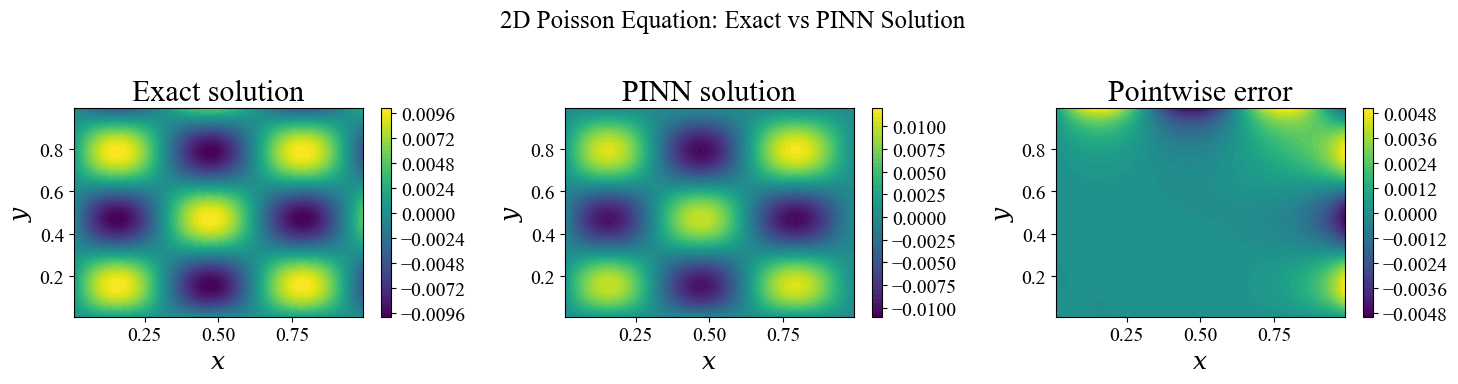

In [125]:
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "dejavuserif",
    "axes.labelsize": 18,
    "font.size": 18,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

with torch.no_grad():
    u_pred = model(xy_test).squeeze().cpu()
    u_exact_cpu = u_test.cpu()
    X_cpu = X_test.cpu()
    Y_cpu = Y_test.cpu()

    u_exact_2d = u_exact_cpu.reshape(X_cpu.shape)
    u_pred_2d = u_pred.reshape(X_cpu.shape)
    error_2d = u_pred_2d - u_exact_2d

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].contourf(X_cpu, Y_cpu, u_exact_2d, levels=50)
axes[0].set_title("Exact solution")
axes[0].set_xlabel(r"$x$")
axes[0].set_ylabel(r"$y$")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(X_cpu, Y_cpu, u_pred_2d, levels=50)
axes[1].set_title("PINN solution")
axes[1].set_xlabel(r"$x$")
axes[1].set_ylabel(r"$y$")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].contourf(X_cpu, Y_cpu, error_2d, levels=50)
axes[2].set_title("Pointwise error")
axes[2].set_xlabel(r"$x$")
axes[2].set_ylabel(r"$y$")
plt.colorbar(im2, ax=axes[2])

fig.suptitle("2D Poisson Equation: Exact vs PINN Solution", fontsize=18)

fig.tight_layout()

fig.savefig(
    "pinn_2d_poisson_exact_pinn_error.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Plot training loss

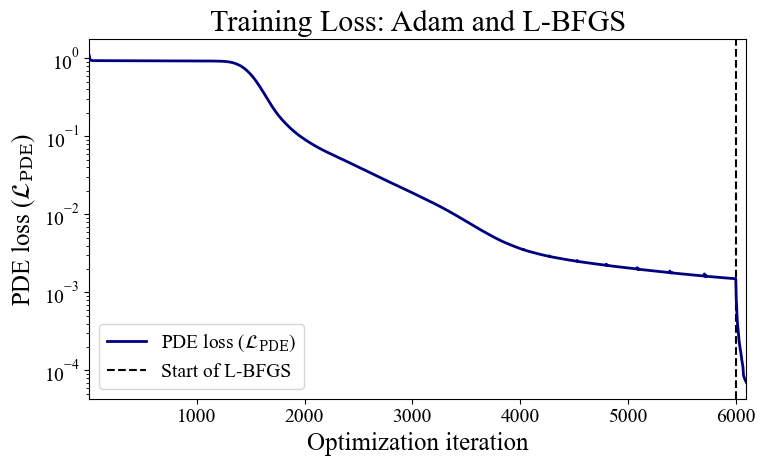

In [141]:
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "dejavuserif",
    "axes.labelsize": 18,
    "font.size": 18,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

# Combined recorded iterations:
# first num_epochs entries = Adam
# remaining entries         = L-BFGS
iterations = np.arange(1, len(loss_history) + 1)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(iterations,loss_history,color="#000080",linewidth=2.0,label=r"PDE loss ($\mathcal{L}_{\mathrm{PDE}}$)",zorder=3,)

# Place the separator between the last Adam epoch and the first recorded L-BFGS step
ax.axvline(x=num_epochs + 0.5,color="k",linestyle="--",linewidth=1.5,label="Start of L-BFGS",zorder=2,)

ax.set_yscale("log")

ax.set_xlabel("Optimization iteration")
ax.set_ylabel(r"PDE loss ($\mathcal{L}_{\mathrm{PDE}}$)")
ax.set_title("Training Loss: Adam and L-BFGS")

ax.set_xlim(1, len(loss_history))

ax.legend(loc="best",frameon=True,)

ax.grid(False)

fig.tight_layout()

#fig.savefig("pinn_2d_poisson_training_loss.png",dpi=300, bbox_inches="tight",)

plt.show()

## Plot training error

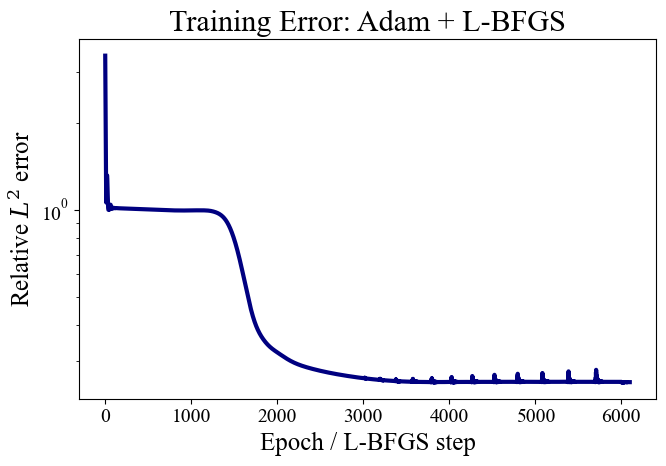

In [144]:
error_color = "#000080"

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(l2_history,color=error_color,lw=3,zorder=3)

ax.set_yscale("log")
ax.set_xlabel(r"Epoch / L-BFGS step")
ax.set_ylabel(r"Relative $L^2$ error")
ax.set_title("Training Error: Adam + L-BFGS")
ax.grid(False)

fig.tight_layout()

#fig.savefig("pinn_2d_poisson_training_error_adam_lbfgs.png",dpi=300,bbox_inches="tight")

plt.show()